## Imports

In [1]:
import comet_ml
from comet_ml import start, end
from comet_ml.integration.pytorch import log_model

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

import tqdm
import os


/usr/local/lib/python3.11/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## Visualization

In [2]:
def _resolve_device(device=None, model=None):
    if device is not None:
        return device
    if model is not None:
        return next(model.parameters()).device
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sample_generator_images(G, z_dim, num_samples=16, device=None):
    device = _resolve_device(device, G)
    G.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        images = G(z)
    return images.cpu()

def discriminator_scores(D, images, device=None):
    device = _resolve_device(device, D)
    D.eval()
    with torch.no_grad():
        if isinstance(images, np.ndarray):
            images = torch.from_numpy(images).float()
        images = images.to(device)
        images = images.view(images.size(0), -1)
        scores = D(images)
    return scores.view(-1).cpu().numpy()

def plot_generated_images_with_scores(
    G,
    D,
    z_dim,
    num_samples=16,
    device=None,
    figsize=(5, 5),
    save_path=None,
    title="Generated samples with D scores",
):
    images = sample_generator_images(G, z_dim, num_samples, device=device)
    scores = discriminator_scores(D, images, device=device)

    n = int(np.sqrt(num_samples))
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(n, n, wspace=0.1, hspace=0.25)

    for i in range(num_samples):
        ax = plt.subplot(gs[i])
        img = images[i].view(28, 28).numpy()
        ax.imshow(img, cmap="Greys_r")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"D-Score: {scores[i]:.2f}", fontsize=8)

    fig.suptitle(title, fontsize=12)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Task 1 and 2

Testing Vanilla GAN with the default loss function and logistic loss function

### Network and Run Settings

In [3]:

# Network hyperparameters
mb_size = 64

# Run settings
epochs_list = [5, 10, 50]

# Model hyperparameters
Z_dim = 1000
h_dim = 128
lr = 1e-3

### 1 - Model: Vanilla GAN

In [4]:
# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the 28x28 image to 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out




### 2 - With Logistic Loss 

In [5]:
class DiscriminatorLogit(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(DiscriminatorLogit, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        return self.fc2(h)

### 1 -Comet settings

In [14]:
# Comet init
# initialize comet
lab2_1 = comet_ml.Experiment(
    api_key="wCXnRD5xewUGxCxBYe8ePt4JY",
    workspace="kanskejoanna",
    project_name="lab2",
    name="model 2.1 - Vanilla GAN with MNIST",
    display_name="model 2.1 - Vanilla GAN with MNIST",
)

# Report multiple hyperparameters using a dictionary:
hyper_params1 = {
   "batch_size": mb_size,
    "Z_dim": Z_dim,    
    "X_dim": X_dim,
    "h_dim": h_dim,
    "lr": lr,
   "steps": epochs_list
}
lab2_1.log_parameters(hyper_params1)

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : frozen_takin_9429
COMET INFO:     url                   : https://www.comet.com/kanskejoanna/lab2/b8ce81ab537841a8858ec85eef9c07a8
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [3112] : (0.0016699734842404723, 1.2835372686386108)
COMET INFO:   Parameters:
COMET INFO:     X_dim      : 784
COMET INFO:     Z_dim      : 1000
COMET INFO:     batch_size : 64
COMET INFO:     h_dim      : 128
COMET INFO:     lr         : 0.001
COMET INFO:     steps      : [5, 10, 50]
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     model graph       

### 2 - Comet Settings

In [15]:
# Comet init
# initialize comet
lab2_2 = comet_ml.Experiment(
    api_key="wCXnRD5xewUGxCxBYe8ePt4JY",
    workspace="kanskejoanna",
    project_name="lab2",
    name="model 2.2 - Vanilla GAN+Logits with MNIST",
    display_name="model 2.2 - Vanilla GAN with MNIST",
)

# Report multiple hyperparameters using a dictionary:
hyper_params2 = {
   "batch_size": mb_size,
    "Z_dim": Z_dim,    
    "X_dim": X_dim,
    "h_dim": h_dim,
    "lr": lr,
   "steps": epochs_list
}
lab2_2.log_parameters(hyper_params2)

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : extreme_temple_5477
COMET INFO:     url                   : https://www.comet.com/kanskejoanna/lab2/5a4255302750457da5953c35055a61e9
COMET INFO:   Parameters:
COMET INFO:     X_dim      : 784
COMET INFO:     Z_dim      : 1000
COMET INFO:     batch_size : 64
COMET INFO:     h_dim      : 128
COMET INFO:     lr         : 0.001
COMET INFO:     steps      : [5, 10, 50]
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1
COMET INFO: 
COMET WARNING: 

## 1 - Functions for Training+Validation and Saving Samples During Training

In [16]:
# Training
def cGANTraining(G, D, loss_fn, train_loader,labname, G_solver, D_solver, epoch):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)
    
    for it, (X_real, labels) in enumerate(t):
        # Prepare real data
        X_real = X_real.float().to(device)

        # Sample noise and labels
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        # ================= Train Discriminator =================
        G_sample = G(z)
        D_real = D(X_real)
        D_fake = D(G_sample.detach())

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ================= Train Generator ====================
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z)
        D_fake = D(G_sample)

        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    # ================= Logging =================
    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    lab2_1.log_metric(f"{labname} - D loss", D_loss_real_total, step=epoch)
    lab2_1.log_metric(f"{labname} - G loss", G_loss_total, step=epoch)
    #lab2_1.log_metrics(f"{labname} - D loss average", D_loss_real_avg, step=epoch)
    #lab2_1.log_metrics(f"{labname} - G loss average", G_loss_avg, step=epoch)

    
    return G, D, G_loss_avg, D_loss_avg




def save_sample(G, epoch, mb_size, Z_dim):
    '''
    Function for saving generated samples from the generator during training.
    It generates a grid of 16 samples and saves it as an image file in the specified output directory.
    The filename is based on the current epoch number, zero-padded to three digits.
    '''
    out_dir = "out_vanila_GAN2"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        ax.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(f'{out_dir}'):
        os.makedirs(f'{out_dir}')

    plt.savefig(f'{out_dir}/epoch_{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)



## 1 - Training and Validation Loop

100%|██████████| 938/938 [00:12<00:00, 77.68it/s]


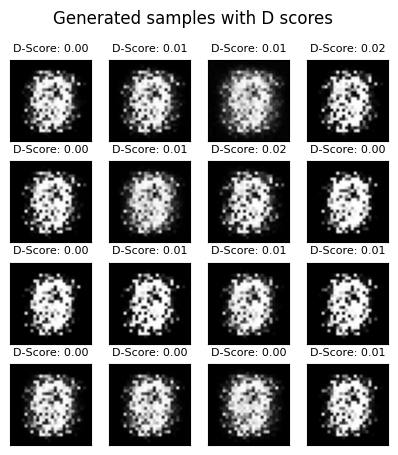

epoch1; D_loss: 0.0730; G_loss: 6.4141
Saved Best Models at epoch 1 | G_loss: 6.4141


100%|██████████| 938/938 [00:11<00:00, 79.36it/s]


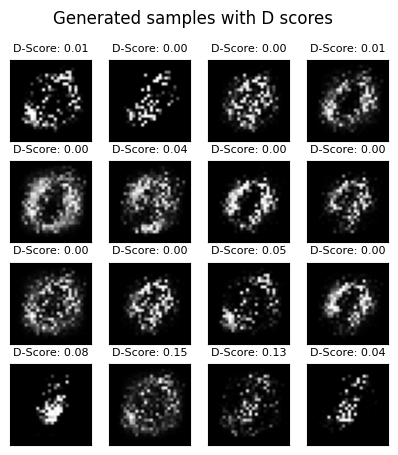

epoch2; D_loss: 0.0320; G_loss: 6.3761
Saved Best Models at epoch 2 | G_loss: 6.3761


100%|██████████| 938/938 [00:11<00:00, 80.79it/s]


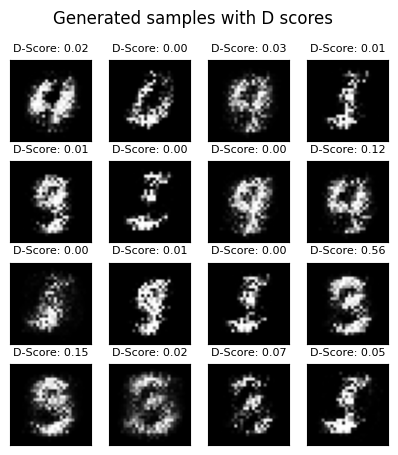

epoch3; D_loss: 0.0650; G_loss: 4.9157
Saved Best Models at epoch 3 | G_loss: 4.9157


100%|██████████| 938/938 [00:10<00:00, 92.61it/s] 


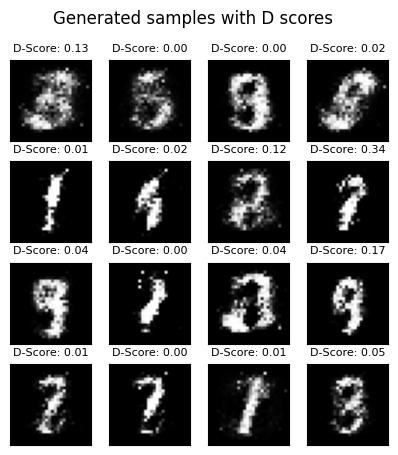

epoch4; D_loss: 0.1346; G_loss: 5.1499


100%|██████████| 938/938 [00:11<00:00, 81.06it/s] 


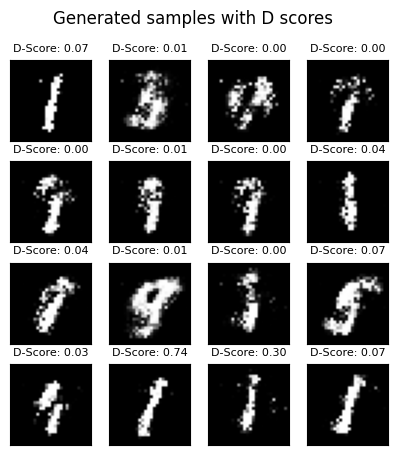

epoch5; D_loss: 0.2370; G_loss: 4.6316
Saved Best Models at epoch 5 | G_loss: 4.6316


100%|██████████| 938/938 [00:11<00:00, 83.35it/s]


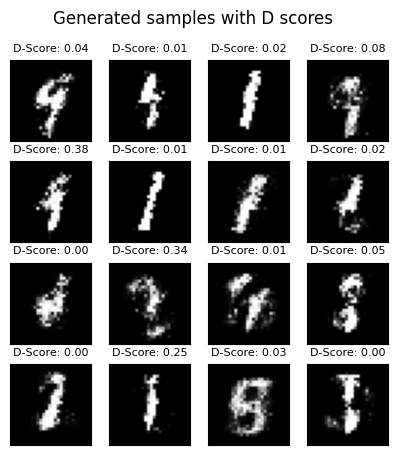

epoch1; D_loss: 0.3414; G_loss: 4.1341
Saved Best Models at epoch 1 | G_loss: 4.1341


100%|██████████| 938/938 [00:11<00:00, 81.82it/s]


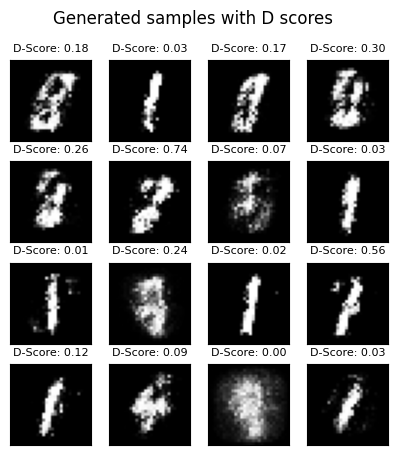

epoch2; D_loss: 0.4430; G_loss: 3.4379
Saved Best Models at epoch 2 | G_loss: 3.4379


100%|██████████| 938/938 [00:11<00:00, 80.55it/s]


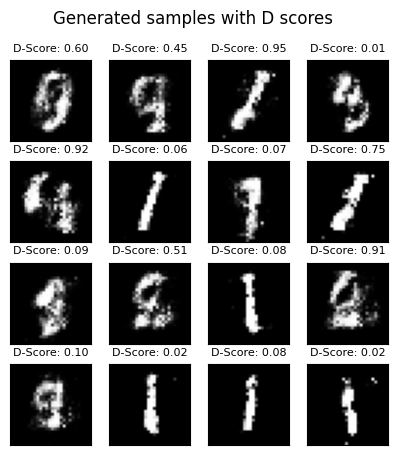

epoch3; D_loss: 0.4857; G_loss: 3.1562
Saved Best Models at epoch 3 | G_loss: 3.1562


100%|██████████| 938/938 [00:10<00:00, 86.70it/s] 


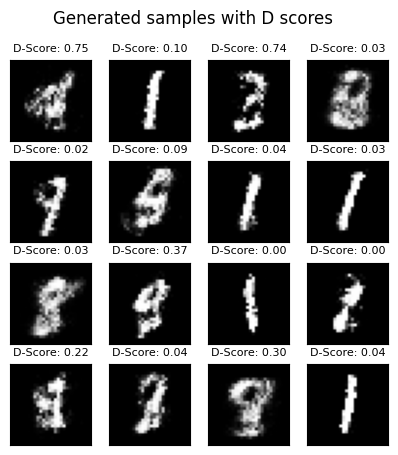

epoch4; D_loss: 0.5486; G_loss: 2.9197
Saved Best Models at epoch 4 | G_loss: 2.9197


100%|██████████| 938/938 [00:11<00:00, 83.28it/s] 


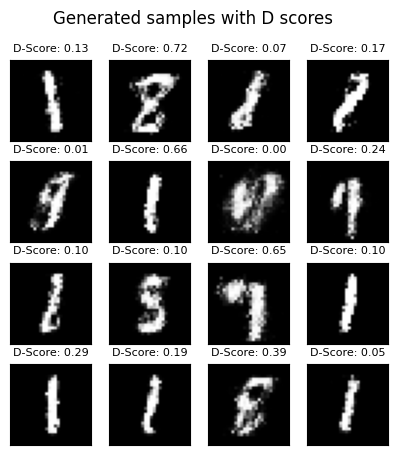

epoch5; D_loss: 0.6091; G_loss: 2.8941
Saved Best Models at epoch 5 | G_loss: 2.8941


100%|██████████| 938/938 [00:12<00:00, 75.95it/s]


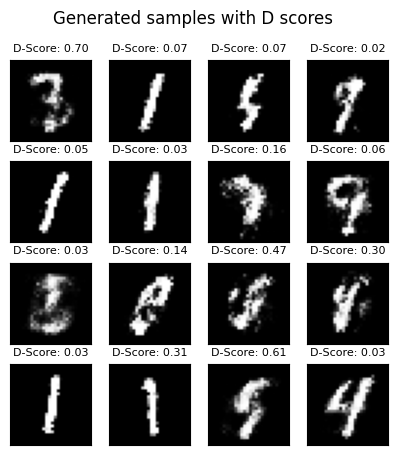

epoch6; D_loss: 0.6482; G_loss: 2.6157
Saved Best Models at epoch 6 | G_loss: 2.6157


100%|██████████| 938/938 [00:11<00:00, 82.54it/s] 


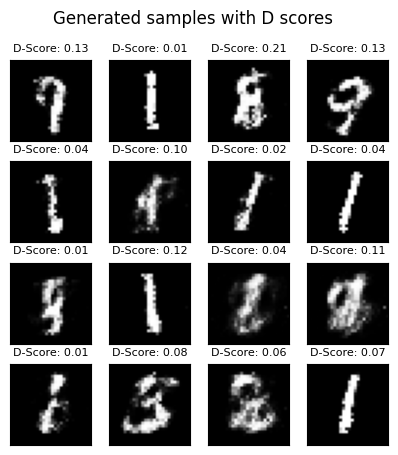

epoch7; D_loss: 0.6704; G_loss: 2.4915
Saved Best Models at epoch 7 | G_loss: 2.4915


100%|██████████| 938/938 [00:10<00:00, 87.63it/s] 


In [ ]:
########################### Main #######################################
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
G1 = Generator(Z_dim, h_dim, X_dim).to(device)
D1 = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G1_solver = optim.Adam(G1.parameters(), lr=lr)
D1_solver = optim.Adam(D1.parameters(), lr=lr)

# Loss function
def my_bce_loss(preds, targets):
    return F.binary_cross_entropy(preds, targets)

loss_fn = nn.BCELoss()
loss_fn = my_bce_loss

best_g_loss = float('inf')  # Initialize best generator loss
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)


for epochs in epochs_list:
    for epoch in range(1, epochs + 1):
        G1, D1, G_loss_avg, D_loss_avg= cGANTraining(G1, D1, 
                                                loss_fn, 
                                                train_loader,"1 - Vanialla GAN",
                                                G1_solver,
                                                D1_solver,
                                                epoch)

        plot_generated_images_with_scores(
        G1,
        D1,
        Z_dim,
        num_samples=16,
        device=device,
        save_path="out_vanilla_GAN1/final_scores.png",
        )

        print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

        if G_loss_avg < best_g_loss:
            best_g_loss = G_loss_avg
            torch.save(G1.state_dict(), os.path.join(save_dir, 'G_best.pth'))
            torch.save(D1.state_dict(), os.path.join(save_dir, 'D_best.pth'))
            print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

        save_sample(G1, epoch, mb_size, Z_dim)
    
lab2_1.end()

# Inference    
# G.load_state_dict(torch.load('checkpoints/G_best.pth'))
# G.eval()

# save_sample(G, "best", mb_size, Z_dim)

## 2 - Training with Logistic Loss

In [ ]:
# Instantiate models
G2 = Generator(Z_dim, h_dim, X_dim).to(device)
D2 = DiscriminatorLogit(X_dim, h_dim).to(device)

# Optimizers
G2_solver = optim.Adam(G2.parameters(), lr=lr)
D2_solver = optim.Adam(D2.parameters(), lr=lr)


loss_fn = nn.BCEWithLogitsLoss()

for epochs in epochs_list:
    for epoch in range(1, epochs + 1):
        G2, D2, G_loss_avg, D_loss_avg= cGANTraining(G2, D2, 
                                                loss_fn, 
                                                train_loader,"2 - Vanialla GAN with Logits",
                                                G2_solver,
                                                D2_solver,
                                                epoch)

        plot_generated_images_with_scores(
        G2,
        D2,
        Z_dim,
        num_samples=16,
        device=device,
        save_path="out_vanilla_GAN2/final_scores.png",
        )

        print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

        if G_loss_avg < best_g_loss:
            best_g_loss = G_loss_avg
            torch.save(G2.state_dict(), os.path.join(save_dir, 'G_best.pth'))
            torch.save(D2.state_dict(), os.path.join(save_dir, 'D_best.pth'))
            print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

        save_sample(G2, epoch, mb_size, Z_dim)
    
lab2_2.end()

## 2 - Comparison With and Without Logistic Loss

bla bla bla

# Task 3
Change GAN code from task 1 to make labeled classes

### 3 - Hyperparameters

### 3 -Training and Validation

# Task 4
Training CNN to classify 4s as 9s

### 4 - Hyperparameters

In [ ]:
epochs = 10

### 4 - Model: GAN

### 4 - Training and Validation

# Task 5

### 5 - Hyperparameters

### 5 - Model: Stable Diffusion

### 5 - Training and Validation

## How does the GAN and Stable Diffusion models compare?